# **Projet : Analyse Prédictive E-Commerce  RFM, Segmentation & Prédiction du Churn**

# 1. Introduction et Description du Dataset

Le dataset utilisé dans cette étude contient **5630 lignes** et **20 colonnes**, chacune représentant une caractéristique liée au comportement client dans un contexte e-commerce. Ces données permettent d’analyser plusieurs aspects : satisfaction, activité d’achat, préférences technologiques et risque de churn.

## 1.1. Types de variables

Le dataset contient trois types principaux de variables :

- **Variables entières (int)** : 7  
- **Variables réelles / flottantes (float)** : 9  
- **Variables catégorielles (object)** : 4  

## 1.2. Détail des attributs

| Attribut | Type | Description |
|---------|------|-------------|
| CustomerID | Entier | Identifiant unique du client |
| Churn | Entier | 1 = client désabonné, 0 = client actif |
| Tenure | Flottant | Ancienneté du client dans l’organisation |
| PreferredLoginDevice | Catégorielle | Appareil préféré pour se connecter |
| CityTier | Entier | Catégorie de la ville (1, 2, 3) |
| WarehouseToHome | Flottant | Distance entre l’entrepôt et la maison |
| PreferredPaymentMode | Catégorielle | Mode de paiement préféré |
| Gender | Catégorielle | Genre du client |
| HourSpendOnApp | Flottant | Nombre d’heures passées sur l’application |
| NumberOfDeviceRegistered | Entier | Nombre d’appareils enregistrés |
| PreferedOrderCat | Catégorielle | Catégorie de commande préférée |
| SatisfactionScore | Entier | Score de satisfaction |
| MaritalStatus | Catégorielle | État civil du client |
| NumberOfAddress | Entier | Nombre d’adresses enregistrées |
| Complain | Entier | 1 = réclamation émise |
| OrderAmountHikeFromlastYear | Flottant | Pourcentage d’augmentation du montant des commandes |
| CouponUsed | Flottant | Nombre de coupons utilisés |
| OrderCount | Flottant | Nombre de commandes passées |
| DaySinceLastOrder | Flottant | Jours depuis la dernière commande |
| CashbackAmount | Flottant | Montant moyen du cashback reçu |

---

# 2. Nettoyage et Préparation des Données

Avant l’analyse, plusieurs étapes de nettoyage ont été appliquées pour garantir la qualité des données.

## 2.1. Traitement des valeurs manquantes

Certaines variables numériques comportaient des valeurs manquantes.  
Pour éviter de modifier la distribution des données, la méthode suivante a été adoptée :

- **Remplacement des valeurs NaN par la médiane**, plus robuste aux valeurs extrêmes.

## 2.2. Traitement des valeurs aberrantes

Pour corriger les valeurs extrêmes pouvant fausser l’analyse :

- Utilisation de la **médiane** pour remplacer ou ajuster les valeurs anormales.
- Application de la méthode **IQR (quantiles)** pour détecter les observations situées hors des bornes acceptables.

---

# 3. Exploration Initiale des Données (EDA)

Une analyse exploratoire a été réalisée afin de mieux comprendre la structure et les relations entre variables :

- Histogrammes pour analyser la distribution des variables numériques.  
- Boxplots pour détecter les valeurs aberrantes (ex. : Tenure, DaySinceLastOrder).  
- Countplot du churn pour visualiser l’équilibre des classes.  
- Barplots pour les variables catégorielles (Login Device, Payment Mode, etc.).  
- Heatmap de corrélation pour étudier les relations entre variables numériques.  
-  pairplot pour observer les relations entre variables (ex. HourSpendOnApp vs OrderCount).  
- Analyse de l’importance des variables via un modèle **Random Forest**.

Cette phase EDA permet d’identifier les tendances clés et les variables influençant le churn, préparant ainsi la phase de modélisation.



In [32]:
# Importation de pipliothéques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec



In [9]:
datax=pd.read_excel(r"C:\Users\Midouni\Desktop\projet\projet_de_formation\projet2\E Commerce Dataset.xlsx" ,sheet_name='E Comm')
datax.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [43]:
datax.shape

(5630, 20)

In [44]:
datax.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [45]:
datax.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [ ]:
datax.isnull().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [10]:
data_copy=datax.copy()

# 1. Nettoygage et praitrétement de données

## 1.1 Nettyoage de data

In [11]:
def convertire_median(data):
  """ fonction qui remplace les valeurs manquantes par la médiane de la colonne
  """
  for col in data.columns:
    if data[col].dtype in ['int64','float64']:
      data[col]=data[col].fillna(data[col].median())
  return data

In [12]:
data=convertire_median(data_copy)
data.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [13]:
data.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [14]:
doublons = data.duplicated()

print(doublons.value_counts())

False    5630
Name: count, dtype: int64


In [15]:
def detect_val_aberrantes(data):
  """ fonction qui détecte les valeurs aberrantes par boit de moustache"""
  for col in data.columns:
    if data[col].dtype in ['int64','float64']:
      plt.boxplot(data[col])
      plt.xlabel(col)
      plt.title(col)
      plt.show()

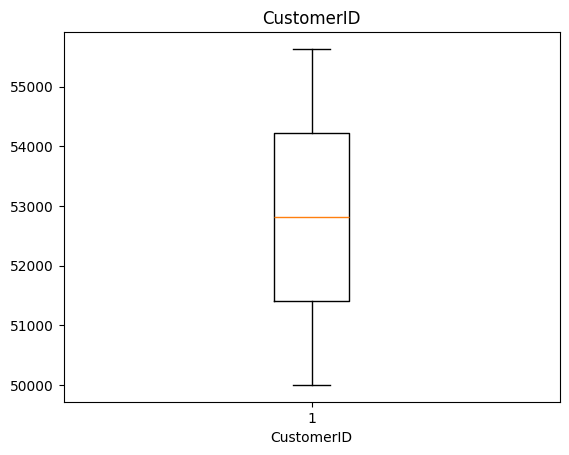

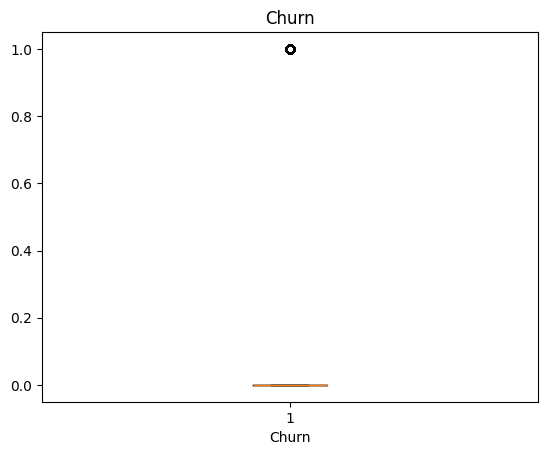

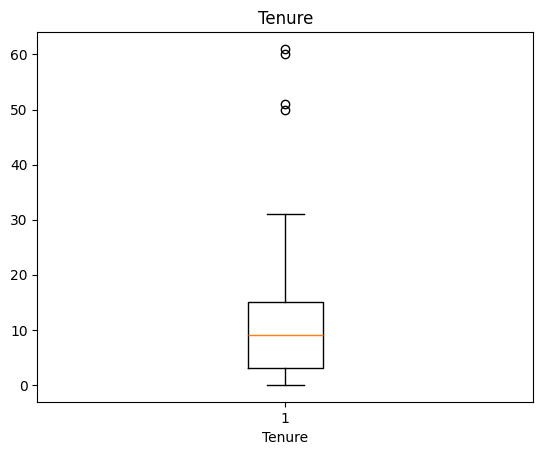

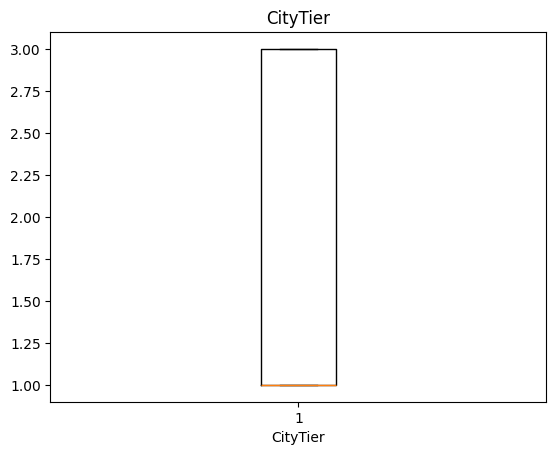

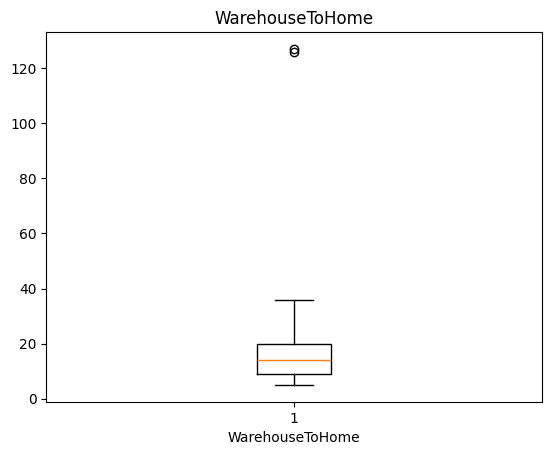

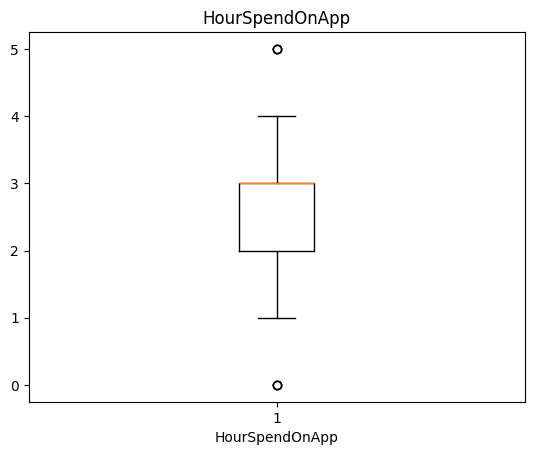

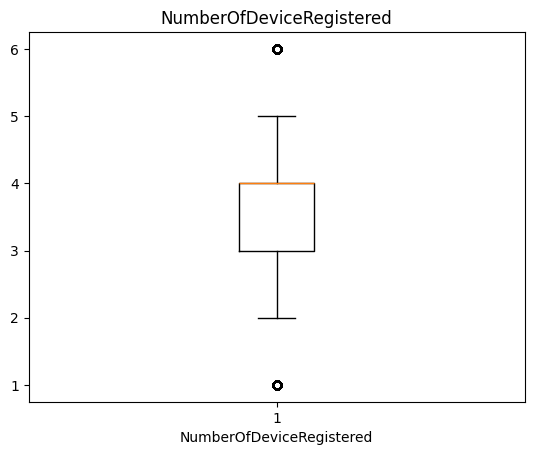

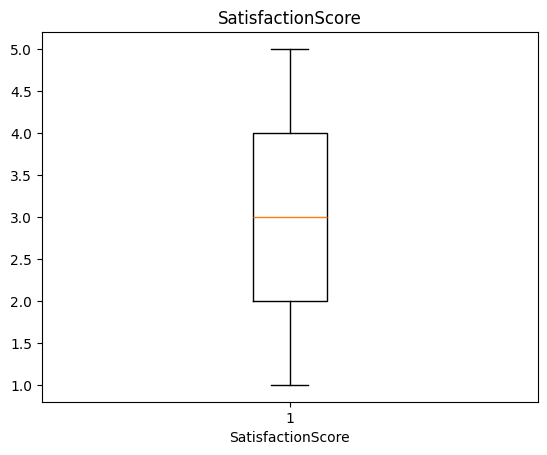

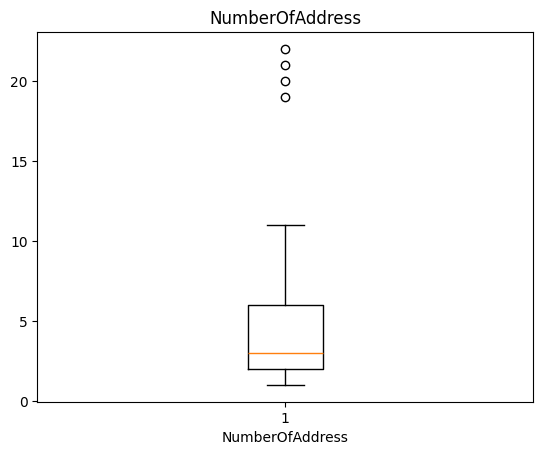

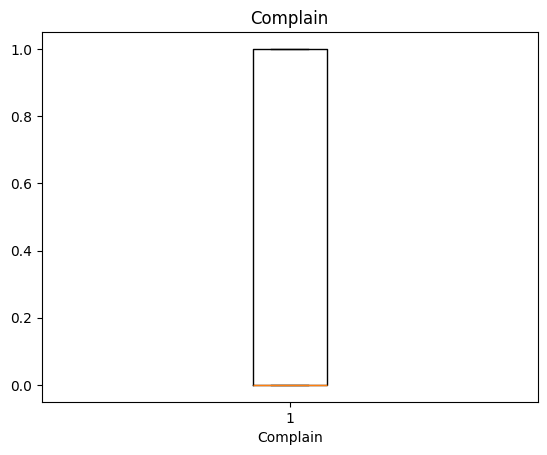

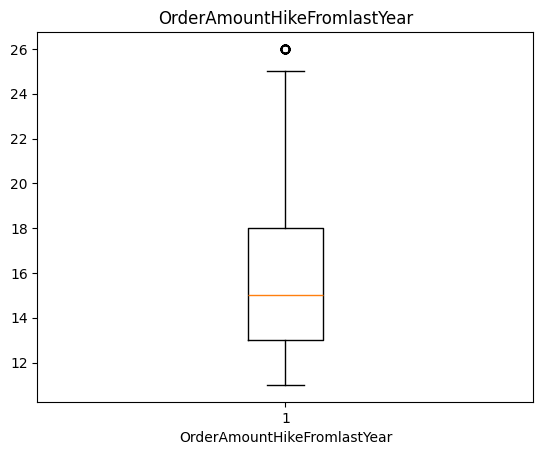

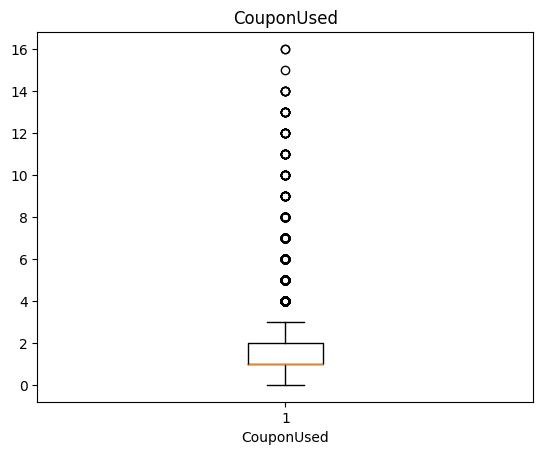

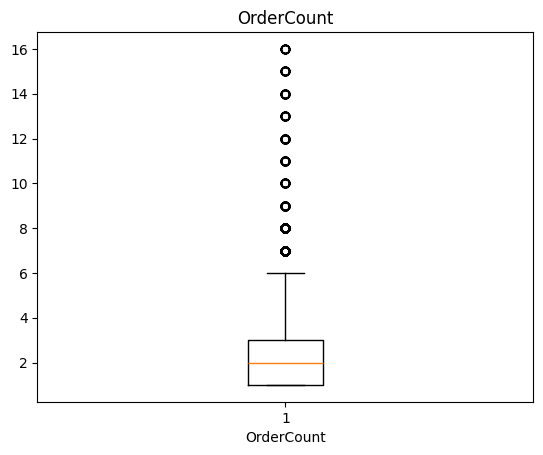

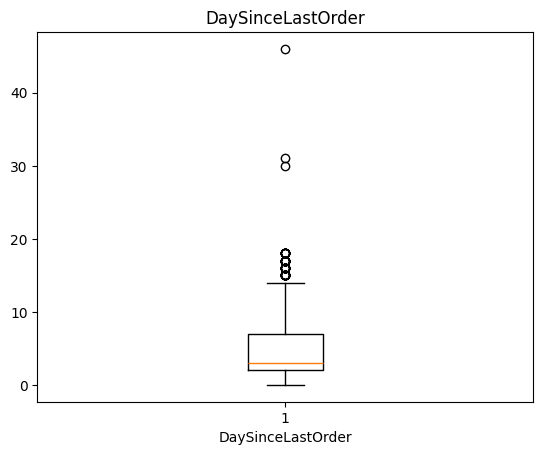

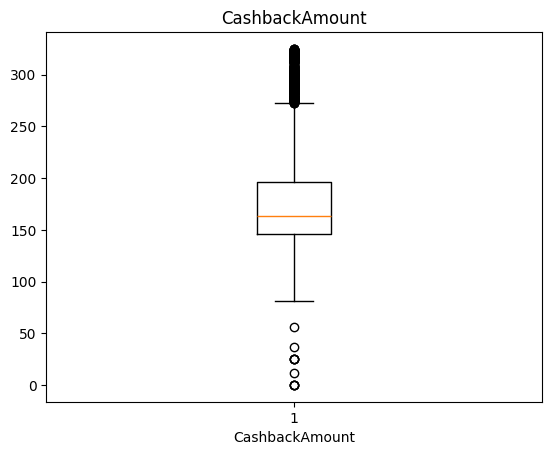

In [16]:
detect_val_aberrantes(data)

**Gérer es valeur abérrante**

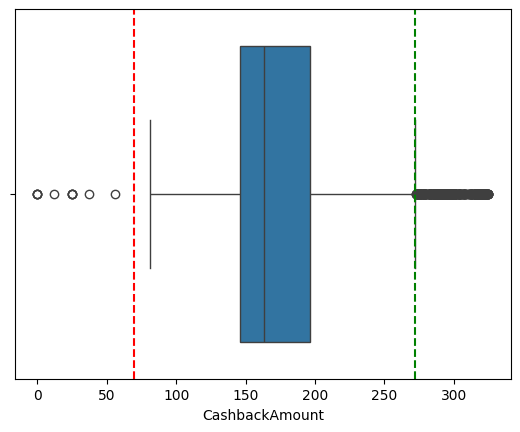

In [17]:
# 1. gestion de valeur manquante de colonne  "CashbackAmount" etape 1
Q1 = data['CashbackAmount'].quantile(0.25)
Q3 = data['CashbackAmount'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Visualisation
sns.boxplot(x=data['CashbackAmount'])
plt.axvline(lower, color='red', linestyle='--')
plt.axvline(upper, color='green', linestyle='--')
plt.show()

# Traitement par winsorization
data['CashbackAmount'] = np.clip(data['CashbackAmount'], lower, upper)

C:\Users\Midouni\AppData\Local\Temp\ipykernel_11496\1634066315.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['CashbackAmount'].fillna(median_value, inplace=True)


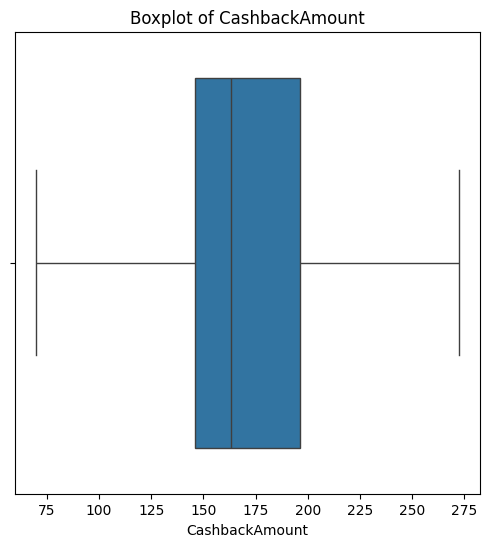

In [18]:
# 1. gestion de valeur manquante de colonne  "CashbackAmount" etape 2
median_value = data['CashbackAmount'].median()
data['CashbackAmount'].fillna(median_value, inplace=True)

# Trassage de graphique
plt.figure(figsize=(6, 6))
sns.boxplot(x=data['CashbackAmount'])
plt.title('Boxplot of CashbackAmount')
plt.show()

nous utilisons deux methodes (methode de quantille et méthode de mediane ) pour gérer les valeur abérrante

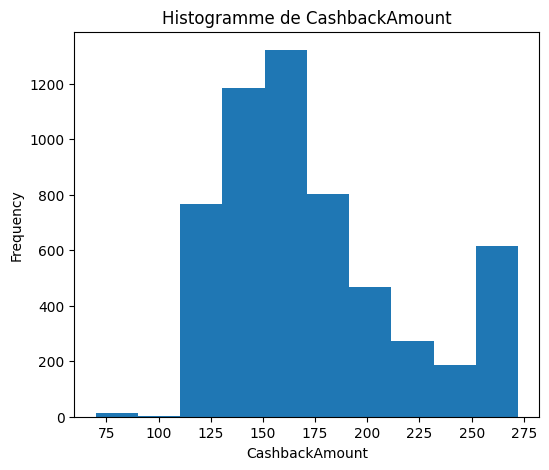

In [19]:

plt.figure(figsize=(6,5))
plt.hist(data['CashbackAmount'])
plt.xlabel('CashbackAmount')
plt.ylabel('Frequency')
plt.title('Histogramme de CashbackAmount')
plt.show()

In [ ]:
#Nombre de jours depuis la dernière commande du clien
data['DaySinceLastOrder'].value_counts()


,count
DaySinceLastOrder,
3.0,1207
2.0,792
1.0,614
8.0,538
0.0,496
7.0,447
4.0,431
9.0,299
5.0,228


In [20]:
median_val = data['DaySinceLastOrder'][data['DaySinceLastOrder'] != 0].median()
data['DaySinceLastOrder'] = data['DaySinceLastOrder'].replace(0, median_val)

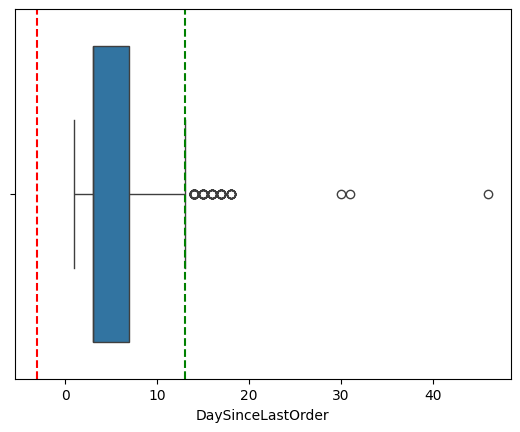

In [21]:
# 2. gestion de valeur manquante de colonne  "DaySinceLastOrder" etape 1
Q1 = data['DaySinceLastOrder'].quantile(0.25)
Q3 = data['DaySinceLastOrder'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Visualisation
sns.boxplot(x=data['DaySinceLastOrder'])
plt.axvline(lower, color='red', linestyle='--')
plt.axvline(upper, color='green', linestyle='--')
plt.show()

# Traitement par winsorization
data['DaySinceLastOrder'] = np.clip(data['DaySinceLastOrder'], lower, upper)

C:\Users\Midouni\AppData\Local\Temp\ipykernel_11496\1924369580.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['DaySinceLastOrder'].fillna(median_value, inplace=True)


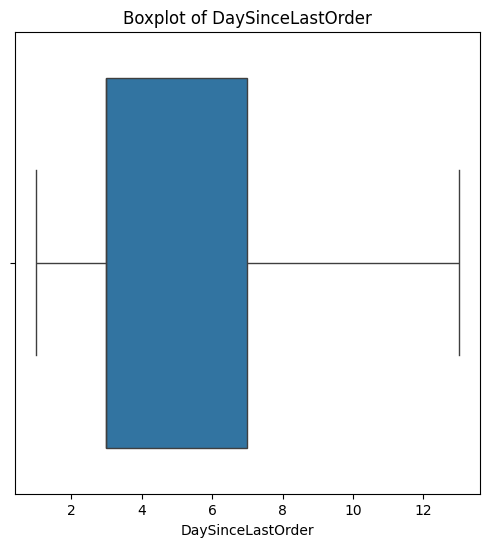

In [22]:
# 2. gestion de valeur manquante de colonne  "DaySinceLastOrder" etape 2
median_value = data['DaySinceLastOrder'].median()
data['DaySinceLastOrder'].fillna(median_value, inplace=True)

# Trassage de graphique
plt.figure(figsize=(6, 6))
sns.boxplot(x=data['DaySinceLastOrder'])
plt.title('Boxplot of DaySinceLastOrder')
plt.show()

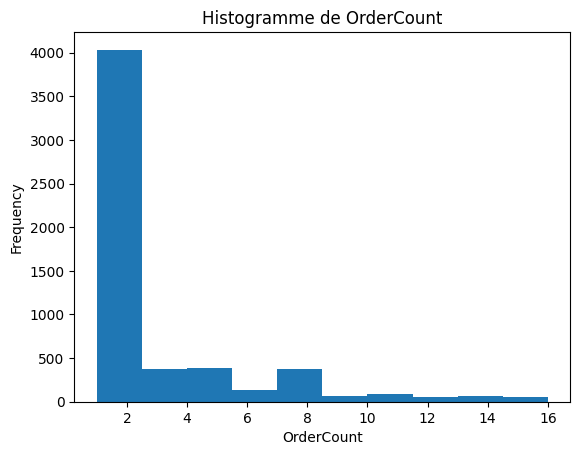

In [23]:
#Nombre total de commandes passées le mois dernier
plt.hist(data['OrderCount'])
plt.xlabel('OrderCount')
plt.ylabel('Frequency')
plt.title('Histogramme de OrderCount')
plt.show()

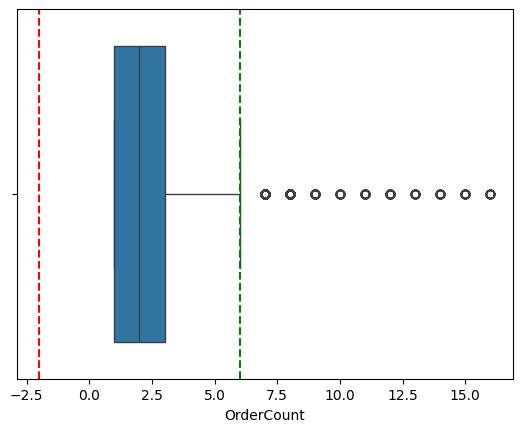

In [24]:
# 3. gestion de valeur manquante de colonne  "OrderCount" etape 1
Q1 = data['OrderCount'].quantile(0.25)
Q3 = data['OrderCount'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Visualisation
sns.boxplot(x=data['OrderCount'])
plt.axvline(lower, color='red', linestyle='--')
plt.axvline(upper, color='green', linestyle='--')
plt.show()

# Traitement par winsorization
data['OrderCount'] = np.clip(data['OrderCount'], lower, upper)

C:\Users\Midouni\AppData\Local\Temp\ipykernel_11496\151716307.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['OrderCount'].fillna(median_value, inplace=True)


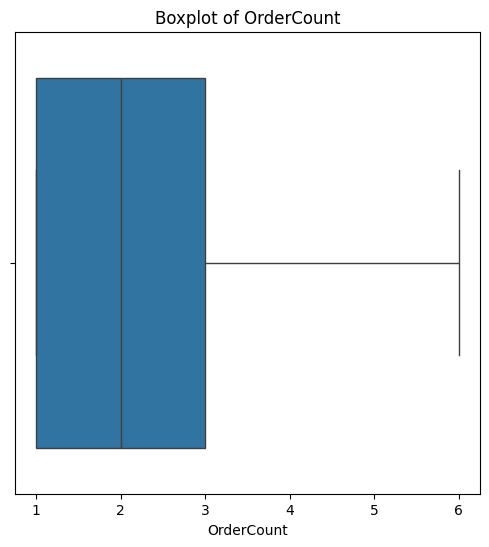

In [25]:
# 3. gestion de valeur manquante de colonne  "OrderCount" etape 2
median_value = data['OrderCount'].median()
data['OrderCount'].fillna(median_value, inplace=True)

# Trassage de graphique
plt.figure(figsize=(6, 6))
sns.boxplot(x=data['OrderCount'])
plt.title('Boxplot of OrderCount')
plt.show()

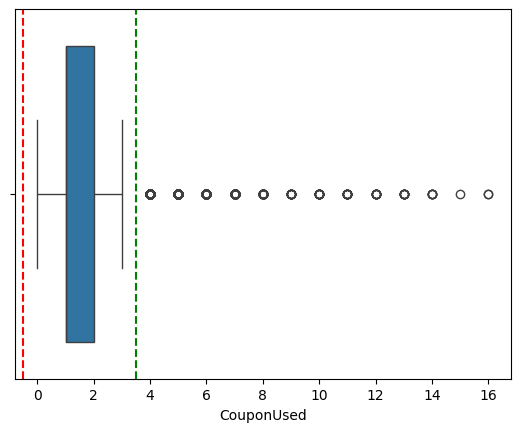

In [26]:

# 4. gestion de valeur manquante de colonne  "CouponUsed" etape 1
Q1 = data['CouponUsed'].quantile(0.25)
Q3 = data['CouponUsed'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Visualisation
sns.boxplot(x=data['CouponUsed'])
plt.axvline(lower, color='red', linestyle='--')
plt.axvline(upper, color='green', linestyle='--')
plt.show()

# Traitement par winsorization
data['CouponUsed'] = np.clip(data['CouponUsed'], lower, upper)

C:\Users\Midouni\AppData\Local\Temp\ipykernel_11496\3931765240.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['CouponUsed'].fillna(median_value, inplace=True)


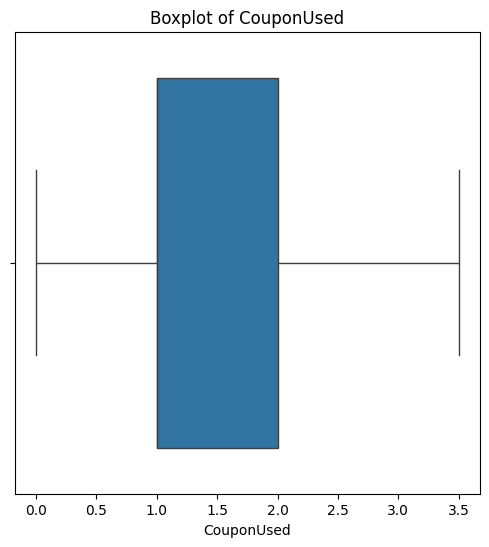

In [27]:
# 4. gestion de valeur manquante de colonne  "OrderCount" etape 2
median_value = data['CouponUsed'].median()
data['CouponUsed'].fillna(median_value, inplace=True)

# Trassage de graphique
plt.figure(figsize=(6, 6))
sns.boxplot(x=data['CouponUsed'])
plt.title('Boxplot of CouponUsed')
plt.show()

In [ ]:
data.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,3.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 1.2. Analyse exploratoire des données

### 1.2.1. Visualisations globales (overview)

####  i. Heatmap de corrélation

        Objectif : voir quelles variables numériques sont liées au churn.

        Variables : toutes les variables numériques

        Graphique : sns.heatmap()

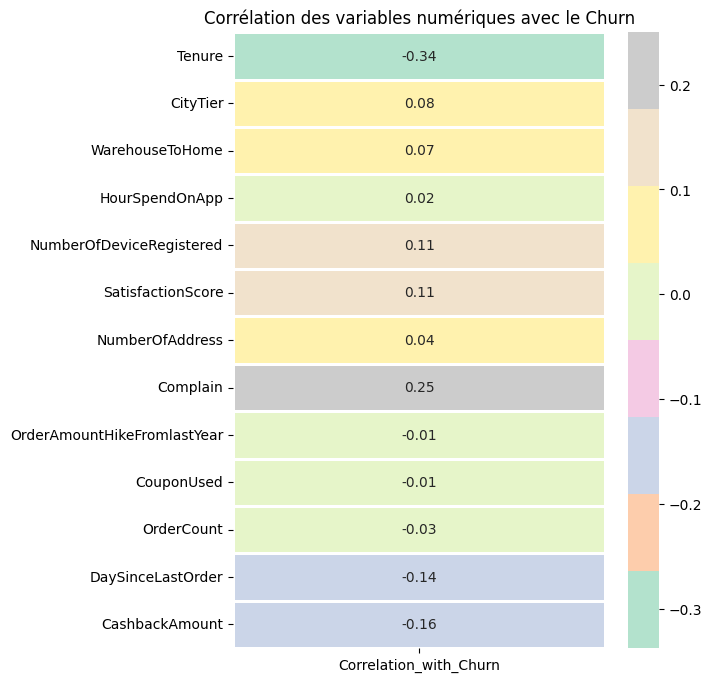

In [ ]:
# Sélection des colonnes numériques
df_numeric = data.select_dtypes(include=['int64', 'float64'])

# Extraire la variable cible
churn = data['Churn']

# Retirer Churn et CustomerID des features
df_numeric = df_numeric.drop(['Churn', 'CustomerID'], axis=1)

# Calculer la corrélation de chaque variable avec Churn
correlation = df_numeric.corrwith(churn)

# Convertir en DataFrame pour heatmap
correlation_df = correlation.to_frame(name='Correlation_with_Churn')

# Heatmap
plt.figure(figsize=(6, 8))
hm = sns.heatmap(correlation_df, annot=True, cmap='Pastel2', fmt=".2f" , linewidths = 2)
plt.title("Corrélation des variables numériques avec le Churn")
plt.show()


**commentaire :** pas de relation directe entre les variable numérique et le "churn"

####  ii. Distribution des types de données

    Objectif : comprendre combien il y a de variables numériques vs catégorielles.

    Graphique : pie chart ou barplot

/tmp/ipython-input-1746126670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_df.index, y='Count', data=type_df, palette='Pastel2')


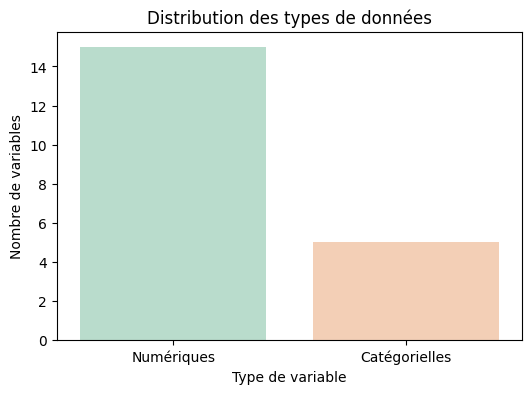

In [ ]:

# Compter les types de données principaux
type_counts = {
    'Numériques': len(data.select_dtypes(include=['int64', 'float64']).columns),
    'Catégorielles': len(data.select_dtypes(include=['object']).columns)
}

# Convertir en DataFrame
type_df = pd.DataFrame.from_dict(type_counts, orient='index', columns=['Count'])

# Barplot
plt.figure(figsize=(6,4))
sns.barplot(x=type_df.index, y='Count', data=type_df, palette='Pastel2')
plt.title("Distribution des types de données")
plt.xlabel("Type de variable")
plt.ylabel("Nombre de variables")
plt.show()


### 1.2.2. Visualisations centrées sur le Churn

#### i. Barplot : Churn Count

       Objectif : voir le déséquilibre de la variable cible.

       Graphique : sns.countplot(x='Churn')

/tmp/ipython-input-886947989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=churn, palette='Pastel2')


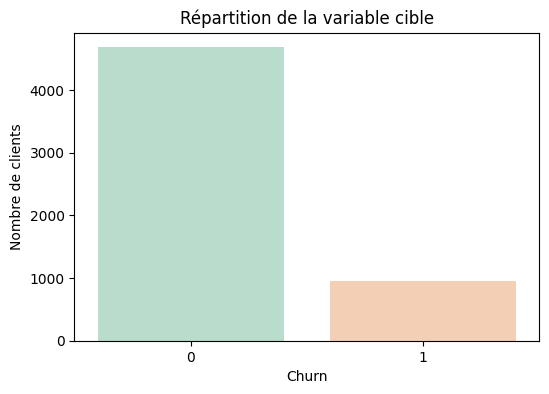

In [ ]:
churn=data['Churn']
plt.figure(figsize=(6,4))
sns.countplot(x=churn, palette='Pastel2')
plt.title("Répartition de la variable cible")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")
plt.show()

**commentaire:** les client qui utulisent toujour l'application sont plus important

#### ii. Boxplot Numeric vs Churn

     Chaque variable numérique vs Churn :

     Exemples :

        Tenure vs Churn

        HourSpendOnApp vs Churn

        DaySinceLastOrder vs Churn

        CashbackAmount vs Churn

        Objectif : détecter les différences entre clients fidèles / churn.

/tmp/ipython-input-759711747.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=data , palette='Pastel2')


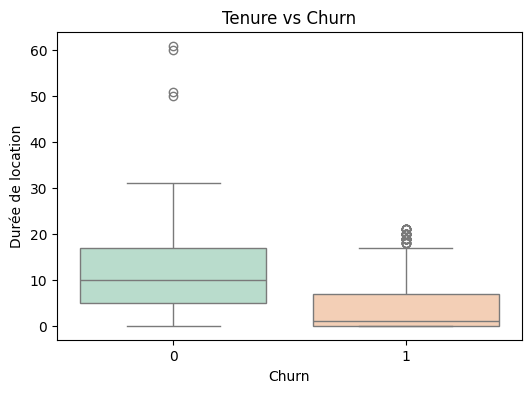

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Tenure', data=data , palette='Pastel2')
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Durée de location")
plt.show()

/tmp/ipython-input-1913392353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='CashbackAmount', data=data , palette='Pastel2')


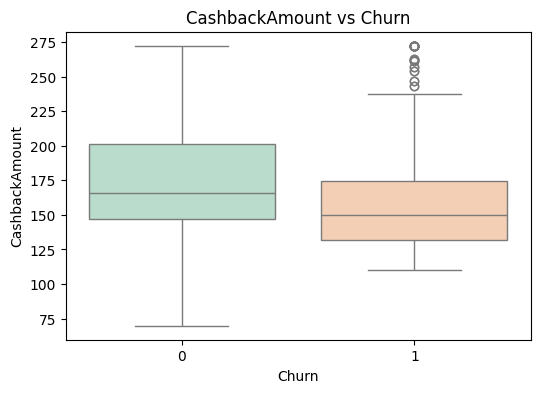

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='CashbackAmount', data=data , palette='Pastel2')
plt.title("Montant moyen du cashback reçu le mois dernier vs Churn")
plt.xlabel("Churn")
plt.ylabel("CashbackAmount")
plt.show()

/tmp/ipython-input-2186805041.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='HourSpendOnApp', data=data , palette='Pastel2')


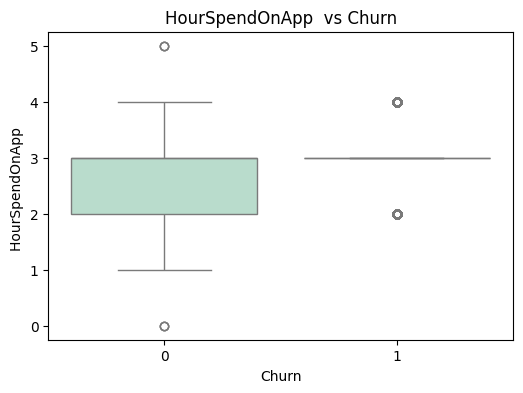

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='HourSpendOnApp', data=data , palette='Pastel2')
plt.title("HourSpendOnApp  vs Churn")
plt.xlabel("Churn")
plt.ylabel("HourSpendOnApp ")
plt.show()

/tmp/ipython-input-1064678620.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='DaySinceLastOrder', data=data , palette='Pastel2')


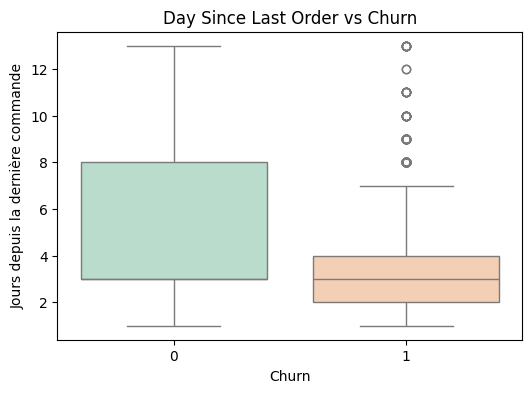

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='DaySinceLastOrder', data=data , palette='Pastel2')
plt.title("Day Since Last Order vs Churn")
plt.xlabel("Churn")
plt.ylabel("Jours depuis la derniére commande")
plt.show()

## Analyse des Boxplots (Tenure, HourSpendOnApp, DaySinceLastOrder, CashbackAmount vs Churn)

La visualisation des différents boxplots comparant les variables numériques avec la variable **Churn** met en évidence un point important :  
la majorité des valeurs observées correspond au **churn = 0**, c’est-à-dire aux *clients toujours actifs*.

Plus précisément :

- **Tenure vs Churn** : les clients actifs (churn = 0) présentent une ancienneté plus élevée que ceux ayant quitté le service. La distribution est beaucoup plus dense du côté des clients actifs.
- **HourSpendOnApp vs Churn** : les clients actifs passent généralement plus d’heures sur l’application, indiquant un engagement plus fort.
- **DaySinceLastOrder vs Churn** : les clients actifs ont passé une commande plus récemment, d’où une valeur plus faible de “jours depuis la dernière commande”.
- **CashbackAmount vs Churn** : les montants de cashback sont également plus élevés du côté des clients actifs, suggérant une utilisation régulière du service.

Globalement, les boxplots révèlent que la classe **0 (client actif)** domine le dataset et présente des comportements plus stables et cohérents, alors que les clients ayant churné (classe 1) sont moins nombreux et montrent des variabilités plus importantes dans leurs valeurs.


####  iii. Barplot (catégorielle vs Churn)

    Exemples :

      PreferredLoginDevice vs Churn

      PreferredPaymentMode vs Churn

      Gender vs Churn

      MaritalStatus vs Churn

      PreferedOrderCat vs Churn

      Objectif : voir les catégories qui quittent le plus.

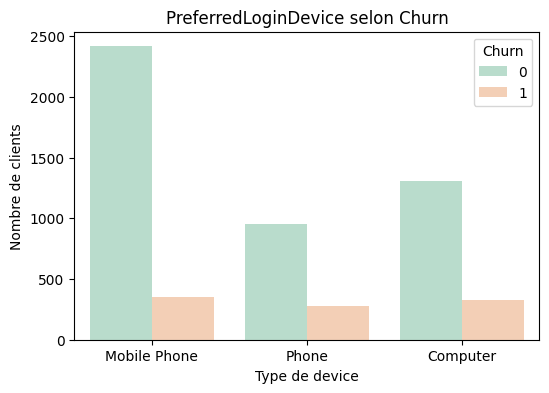

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='PreferredLoginDevice', hue='Churn', palette='Pastel2')
plt.title("PreferredLoginDevice selon Churn")
plt.xlabel("Type de device")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.show()


In [ ]:
data['PreferredLoginDevice'].value_counts()

,count
PreferredLoginDevice,
Mobile Phone,2765
Computer,1634
Phone,1231


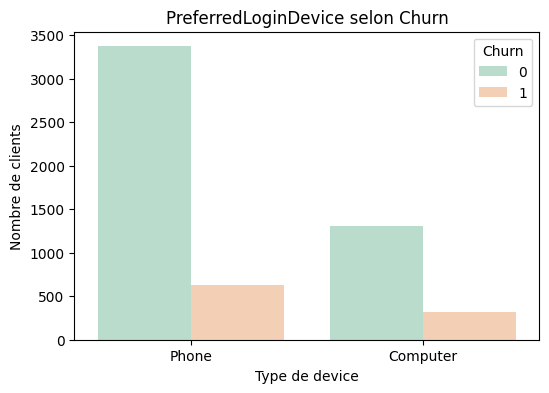

In [ ]:
data['PreferredLoginDevice']=data['PreferredLoginDevice'].replace('Mobile Phone','Phone')
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='PreferredLoginDevice', hue='Churn', palette='Pastel2')
plt.title("PreferredLoginDevice selon Churn")
plt.xlabel("Type de device")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.show()


In [ ]:
data['PreferredLoginDevice'].value_counts()


,count
PreferredLoginDevice,
Phone,3996
Computer,1634


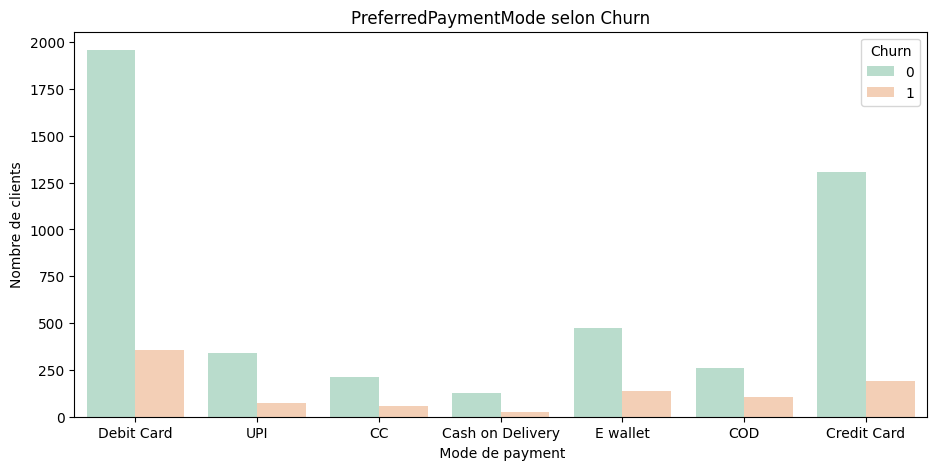

In [ ]:
plt.figure(figsize=(11,5))
sns.countplot(data=data, x='PreferredPaymentMode', hue='Churn', palette='Pastel2')
plt.title("PreferredPaymentMode selon Churn")
plt.xlabel(" Mode de payment")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.show()

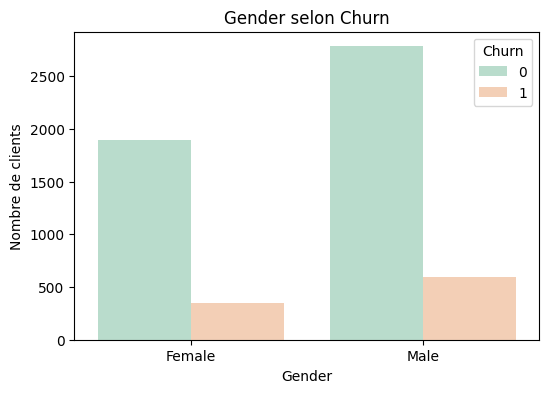

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Gender', hue='Churn', palette='Pastel2')
plt.title("Gender selon Churn")
plt.xlabel("Gender")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.show()

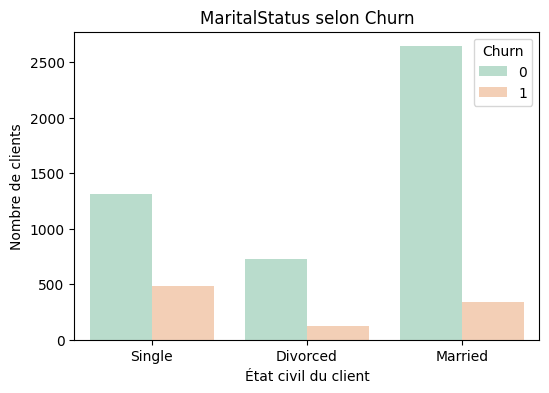

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='MaritalStatus', hue='Churn', palette='Pastel2')
plt.title("MaritalStatus selon Churn")
plt.xlabel("État civil du client")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.show()

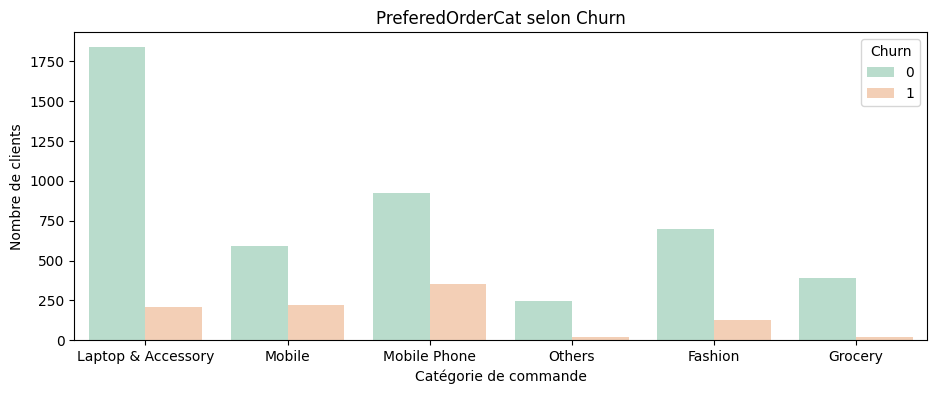

In [ ]:
plt.figure(figsize=(11,4))
sns.countplot(data=data, x='PreferedOrderCat', hue='Churn', palette='Pastel2')
plt.title("PreferedOrderCat selon Churn")
plt.xlabel("Catégorie de commande")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.show()

## Analyse des Barplots : Variables Catégorielles vs Churn

L’analyse des barplots portant sur les variables catégorielles  
(**PreferredLoginDevice**, **PreferredPaymentMode**, **Gender**, **MaritalStatus**, **PreferedOrderCat**) montre plusieurs tendances importantes concernant les clients actifs (churn = 0).

### • PreferredLoginDevice vs Churn
La majorité des clients actifs préfèrent se connecter via **leur téléphone**.  
Le **mobile** apparaît donc comme l’appareil dominant pour l’accès au service, indiquant un usage fréquent et une forte dépendance à l'application mobile.

### • PreferredPaymentMode vs Churn
Les modes de paiement les plus utilisés par les clients actifs sont :
- **Debit Card**
- **Credit Card**

Ces deux moyens représentent la grande majorité des transactions, ce qui suggère une préférence pour des méthodes rapides et sécurisées.

### • Gender vs Churn
On observe que la plupart des clients actifs sont **de sexe masculin**, ce qui constitue la catégorie démographique dominante dans l’échantillon.

### • MaritalStatus vs Churn
La majorité des clients actifs sont **mariés**, montrant que cette catégorie semble plus stable et plus fidèle au service.

### • PreferedOrderCat vs Churn
Les catégories de produits les plus populaires parmi les clients actifs sont :
- **Laptop**
- **Accessories**
- **Phone**
- **Fashion**

Ces catégories représentent la majorité des achats des clients fidèles au service.

### • Observation générale
Les clients non actifs (churn = 1) sont présents en proportion beaucoup plus faible dans toutes les catégories.  
Leurs comportements sont moins marqués, ce qui montre que la majorité des tendances identifiées provient principalement des clients actifs.

En résumé, les barplots indiquent que les clients qui restent dans le service :
- utilisent principalement le **téléphone** comme appareil,
- paient surtout par **carte bancaire**,
- sont majoritairement **hommes** et **mariés**,
- et préfèrent acheter des **produits technologiques et de mode**.


## 1.2.3. Visualisations comportementales

####   i. Histogrammes des variables numériques

       Tenure

       HourSpendOnApp

       WarehouseToHome

       CashbackAmount

       OrderCount

       CouponUsed

       Graphique : sns.histplot()

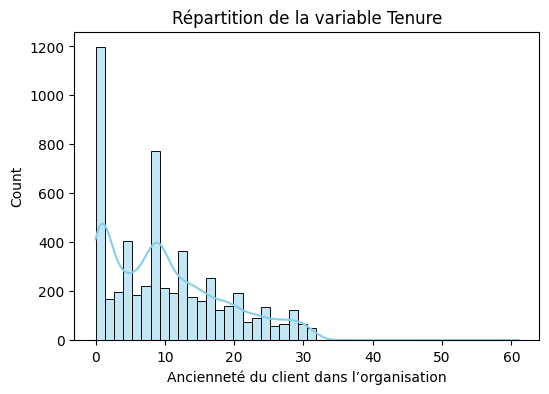

In [68]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x='Tenure', kde=True, color='skyblue')
plt.title("Répartition de la variable Tenure")
plt.xlabel("Ancienneté du client dans l’organisation")
plt.show()

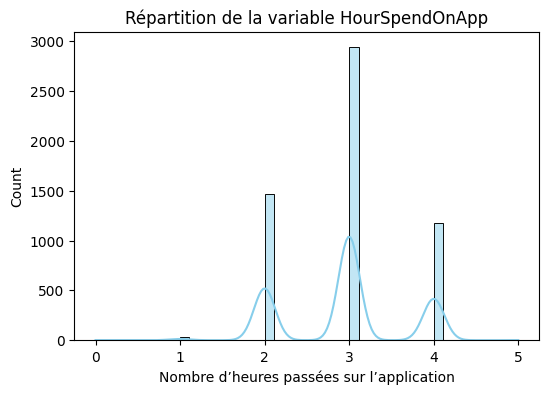

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x='HourSpendOnApp', kde=True, color='skyblue')
plt.title("Répartition de la variable HourSpendOnApp")
plt.xlabel("Nombre d’heures passées sur l’application")
plt.show()

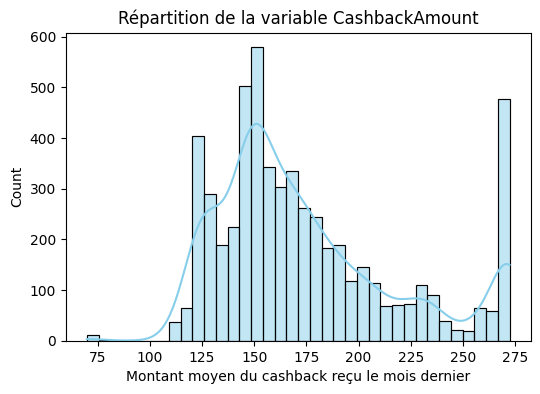

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x='CashbackAmount', kde=True, color='skyblue')
plt.title("Répartition de la variable CashbackAmount")
plt.xlabel("Montant moyen du cashback reçu le mois dernier")
plt.show()

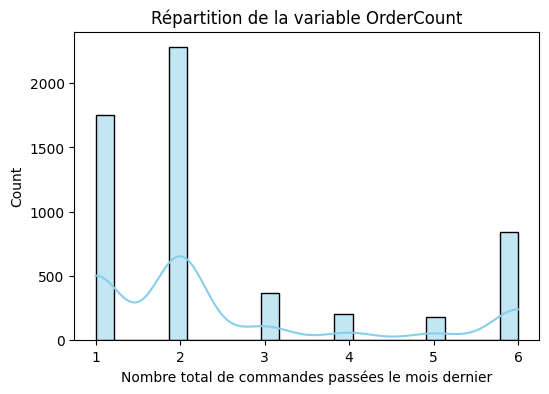

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x='OrderCount', kde=True, color='skyblue')
plt.title("Répartition de la variable OrderCount")
plt.xlabel("Nombre total de commandes passées le mois dernier")
plt.show()

In [ ]:
#data['OrderCount'].value_counts()

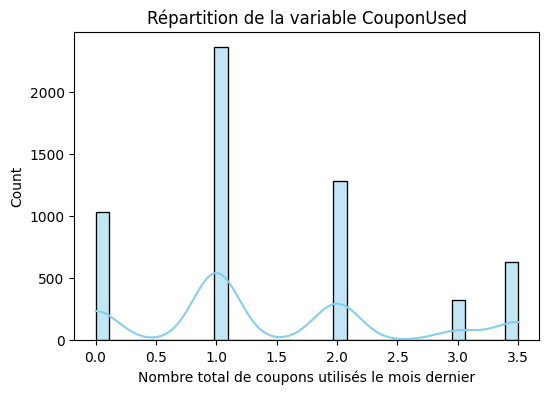

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x='CouponUsed', kde=True, color='skyblue')
plt.title("Répartition de la variable CouponUsed")
plt.xlabel("Nombre total de coupons utilisés le mois dernier")
plt.show()

## Analyse des Histogrammes (sns.histplot)

L’analyse des histogrammes des variables numériques  
(**Tenure**, **HourSpendOnApp**, **WarehouseToHome**, **CashbackAmount**, **OrderCount**, **CouponUsed**) permet de mieux comprendre leur répartition dans le dataset.

### • Tenure
La répartition de l’ancienneté (**Tenure**) est fortement concentrée entre **0 et 10 mois**.  
Cela montre que la majorité des clients sont relativement récents dans l’entreprise.

### • HourSpendOnApp
Pour la variable **HourSpendOnApp**, on observe que la plupart des clients passent environ **3 heures** sur l’application ou le site web.  
Cette durée indique un niveau d’activité modéré mais régulier.

### • WarehouseToHome
La variable **WarehouseToHome** montre une dispersion plus large, ce qui signifie que la distance entre l’entrepôt et le domicile varie beaucoup selon les clients.

### • CashbackAmount
La distribution du **CashbackAmount** est principalement concentrée entre **125 et 150 unités**.  
Cette plage représente la fréquence la plus élevée, indiquant que la plupart des clients reçoivent un cashback modéré mais stable.

### • OrderCount
On remarque que la majorité des clients ont un **OrderCount d’environ 2 commandes** durant le mois précédent.  
Cela correspond à plus de **2000 clients** dans le dataset, ce qui en fait la fréquence la plus dominante.

### • CouponUsed
La variable **CouponUsed** montre une forte concentration autour de **1 coupon utilisé**.  
Ce niveau est observé chez plus de **2000 clients**, indiquant que l’utilisation de coupons est courante mais souvent limitée à une seule utilisation mensuelle.

---

### • Conclusion générale
Les histogrammes montrent que :
- les clients sont majoritairement récents,
- passent un temps modéré sur l’application,
- effectuent un faible nombre de commandes,
- reçoivent un cashback compris entre 125 et 150,
- et utilisent souvent un seul coupon.

Ces tendances décrivent un comportement global assez homogène et régulier au sein de la majorité des clients.


#### ii. Pairplot des variables numériques

    Objectif : détecter des relations internes

    Graphique : sns.pairplot(numerical_df, hue='Churn')

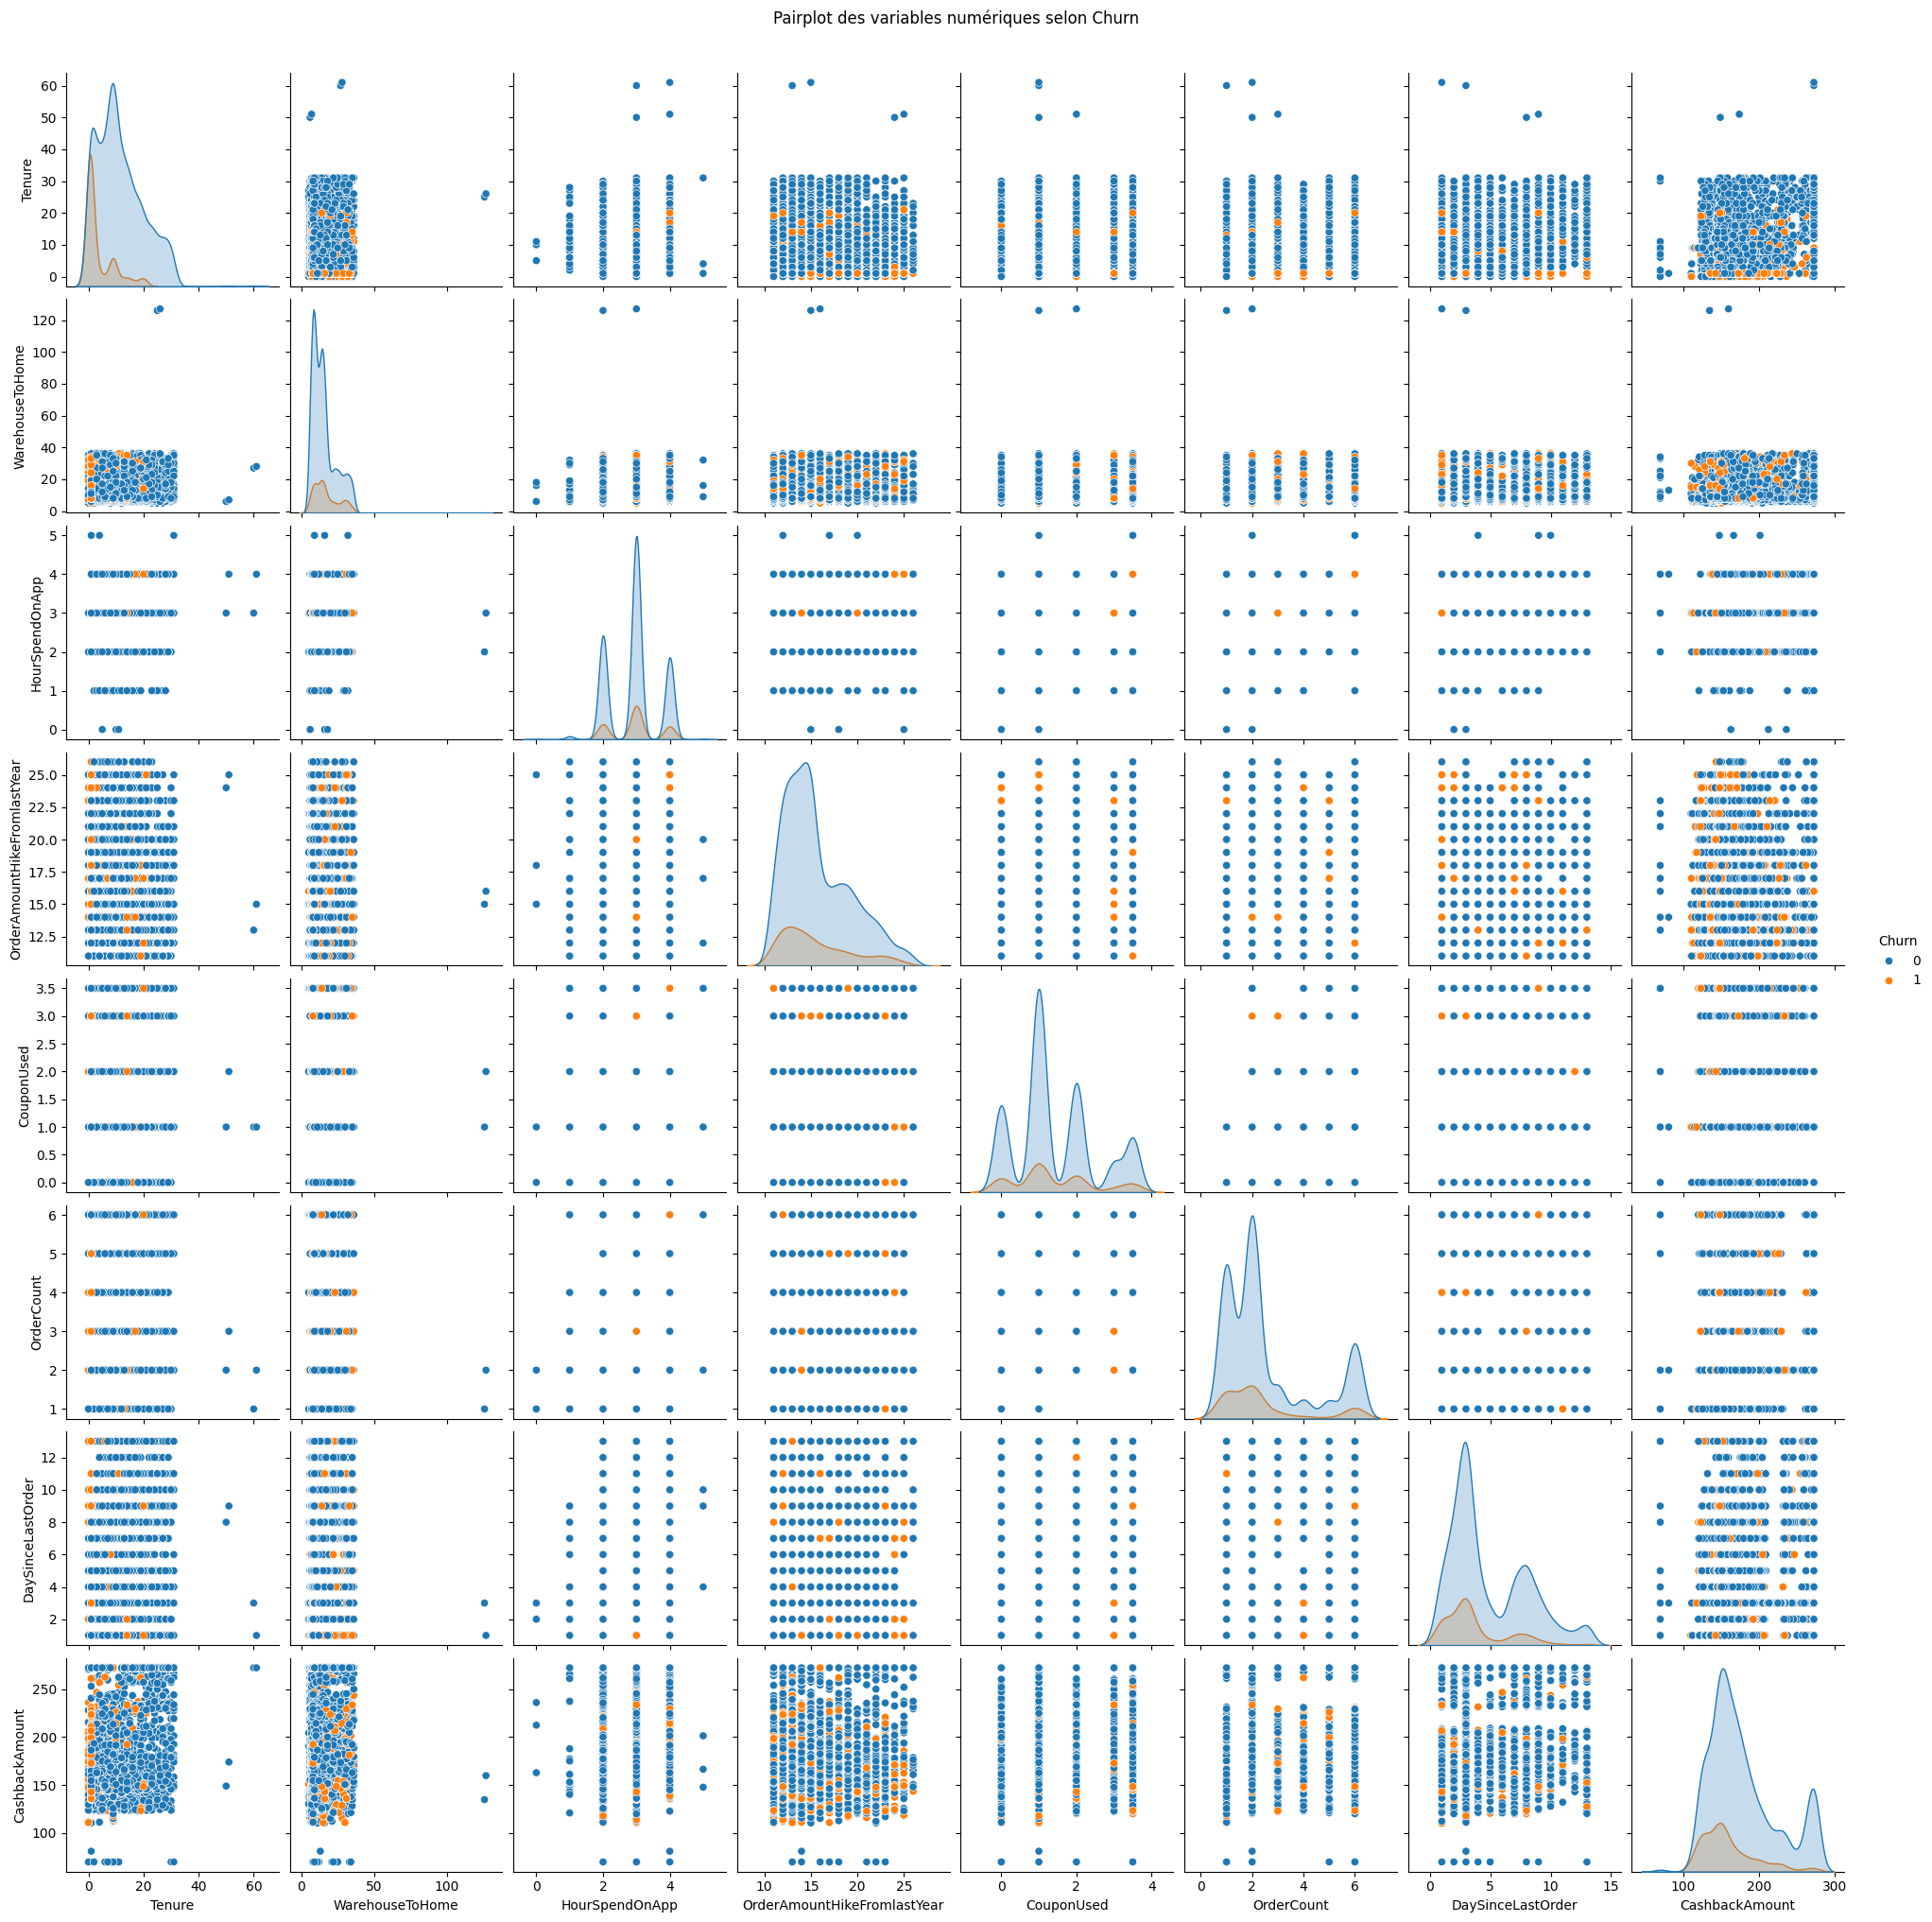

In [ ]:
var_Numérique_continuess=data[['Tenure','WarehouseToHome' ,'HourSpendOnApp','OrderAmountHikeFromlastYear'
,'CouponUsed','OrderCount' ,'DaySinceLastOrder','CashbackAmount','Churn']]
sns.pairplot(var_Numérique_continuess, hue='Churn')
plt.suptitle("Pairplot des variables numériques selon Churn", y=1.02)
plt.show()


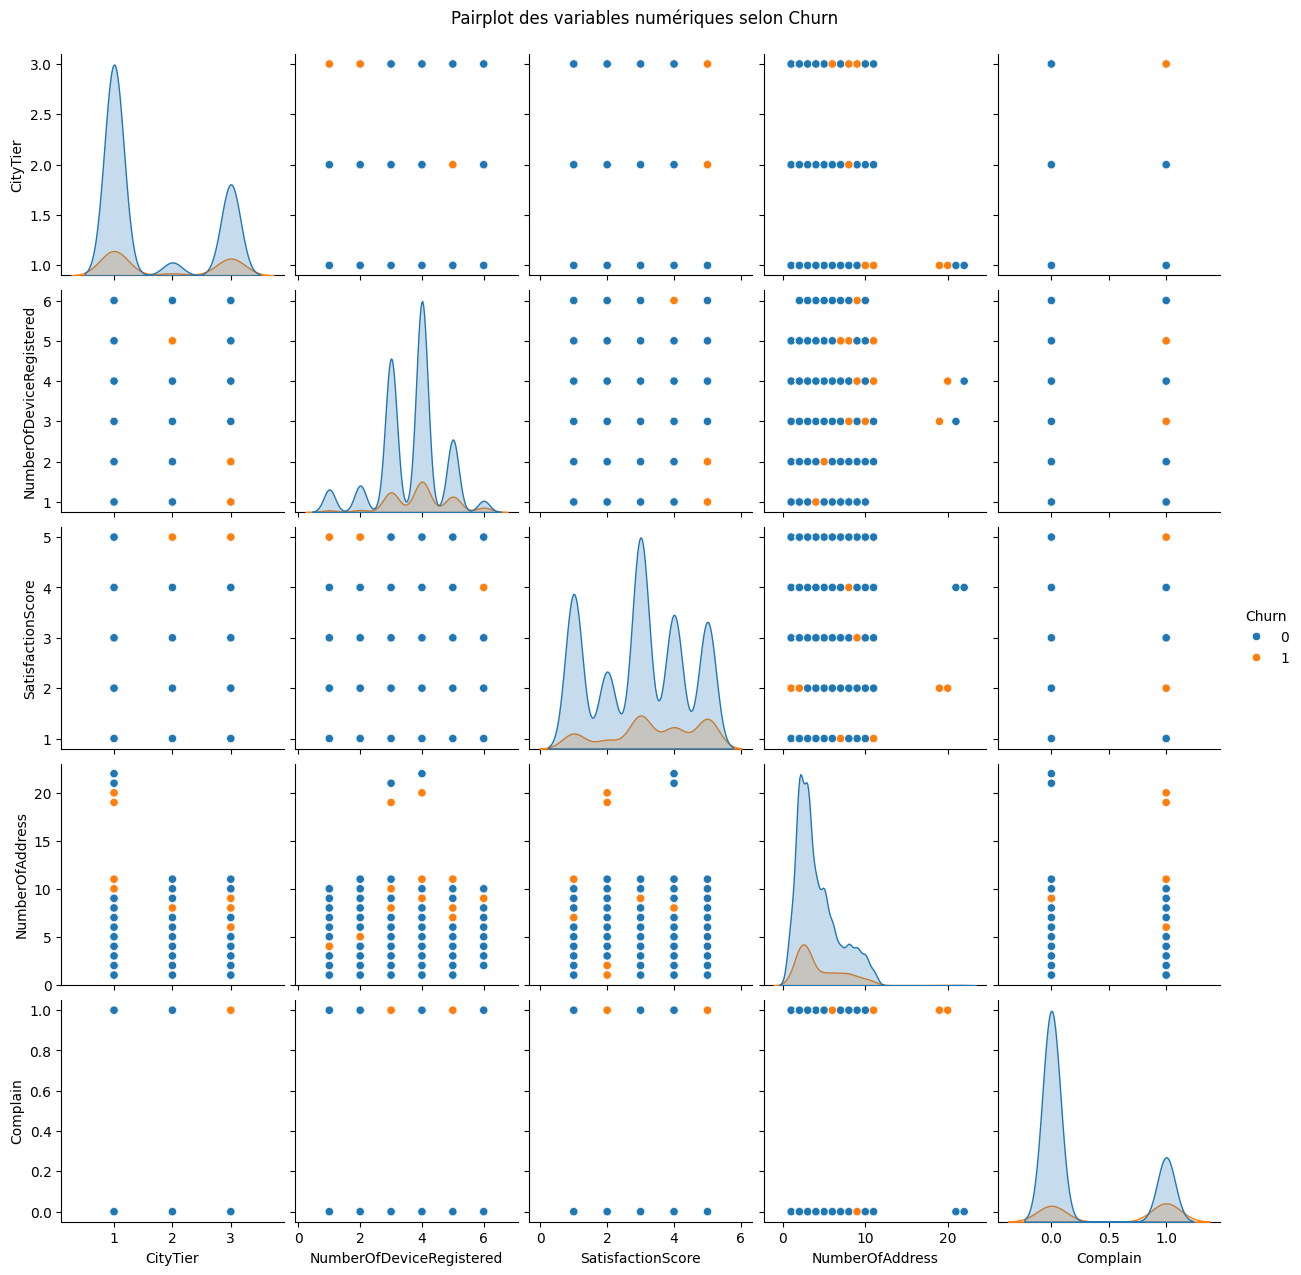

In [ ]:
var_Numérique_discrètes=data[['CityTier' ,'NumberOfDeviceRegistered','SatisfactionScore'
,'NumberOfAddress','Complain' ,'Churn']]
sns.pairplot(var_Numérique_discrètes, hue='Churn')
plt.suptitle("Pairplot des variables numériques selon Churn", y=1.02)
plt.show()


### 1.2.3. Analyse sociodémographique

   #### i. Barplot : CityTier

       Répartition des clients selon CityTier (Catégorie de la ville (1, 2, 3))

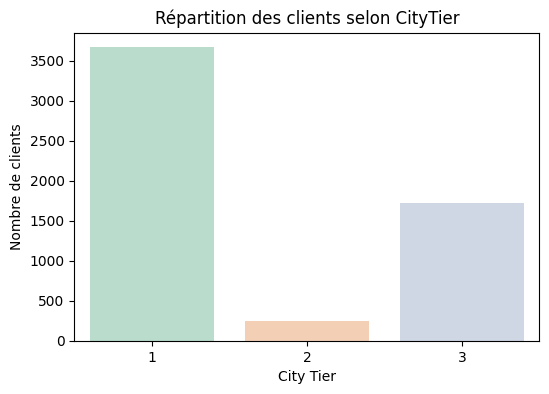

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='CityTier', data=data, hue='CityTier', palette='Pastel2', legend=False)
plt.title("Répartition des clients selon CityTier")
plt.xlabel("City Tier")
plt.ylabel("Nombre de clients")
plt.show()


#### ii. Comparaison CityTier vs Churn

       Voir si certains types de villes churnent plus.

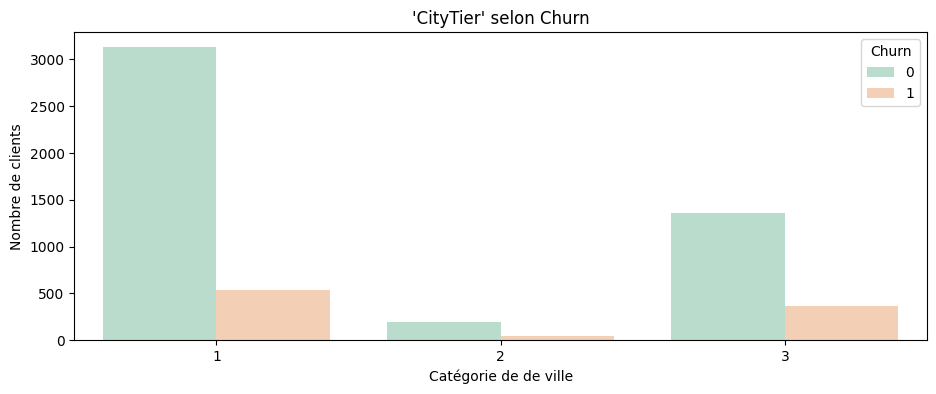

In [ ]:
plt.figure(figsize=(11,4))
sns.countplot(data=data, x='CityTier', hue='Churn', palette='Pastel2')
plt.title("'CityTier' selon Churn")
plt.xlabel("Catégorie de de ville")
plt.ylabel("Nombre de clients")
plt.legend(title="Churn")
plt.show()

 #### iii. Gender Distribution

     Gender vs Churn

     Gender vs PreferredOrderCat

     Gender vs PaymentMode

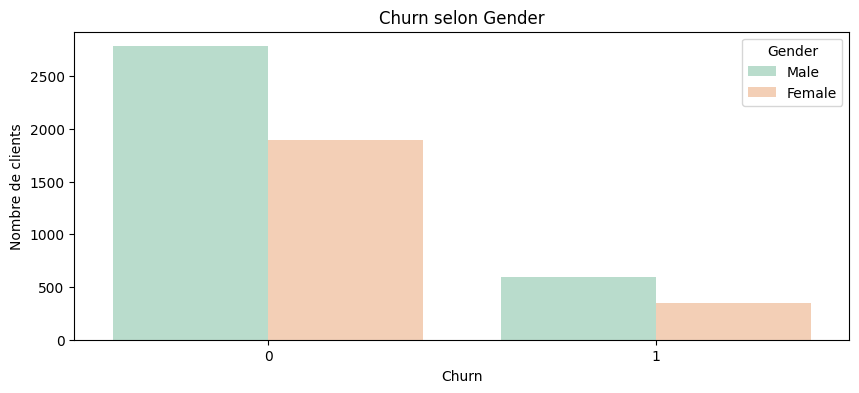

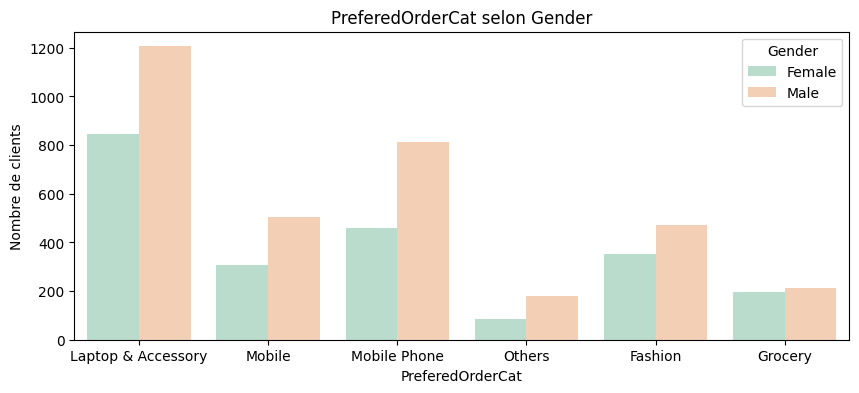

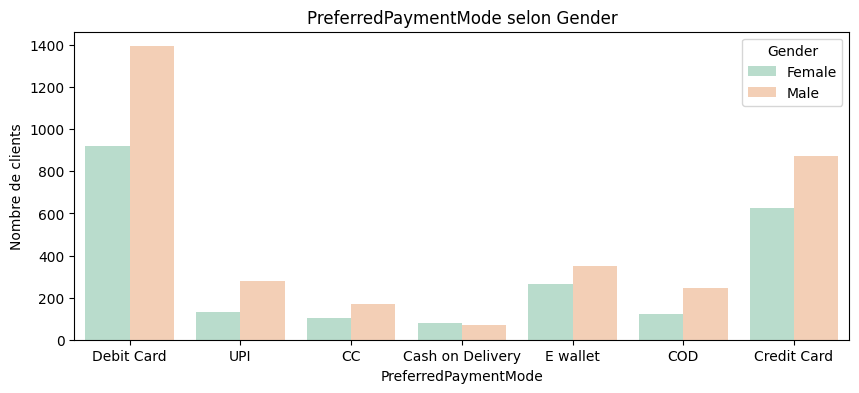

In [ ]:
val_df=data[['Churn','PreferedOrderCat','PreferredPaymentMode']]
gender=data['Gender']

for col in val_df.columns:
    plt.figure(figsize=(10,4))
    sns.countplot(x=col, data=data, hue='Gender', palette='Pastel2')
    plt.title(f"{col} selon Gender")
    plt.xlabel(col)
    plt.ylabel("Nombre de clients")
    plt.legend(title="Gender")
    plt.show()

### 1.2.4. Visualisations sur les commandes

#### i. Barplot OrderCount

       Répartition des commandes par client

/tmp/ipython-input-1214295064.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='OrderCount', data=data, palette='Pastel2')


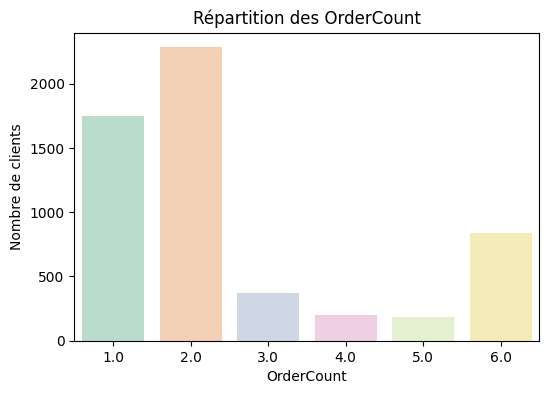

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='OrderCount', data=data, palette='Pastel2')
plt.title("Répartition des OrderCount")
plt.xlabel("OrderCount")
plt.ylabel("Nombre de clients")
plt.show()


#### ii. CouponUsed vs Churn

    Les clients sensibles aux promos quittent-ils moins ?

/tmp/ipython-input-1537971118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='CouponUsed', data=data, palette='Pastel2')


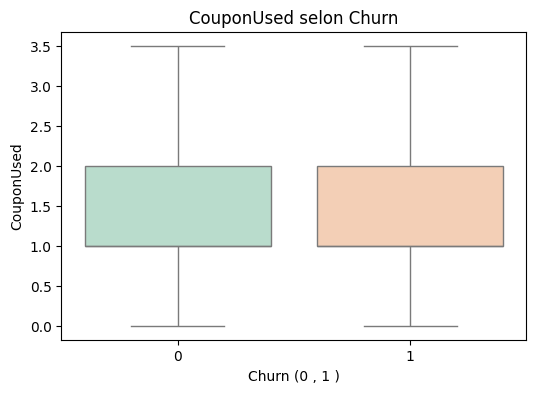

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='CouponUsed', data=data, palette='Pastel2')
plt.title("CouponUsed selon Churn")
plt.xlabel("Churn (0 , 1 )")
plt.ylabel("CouponUsed")
plt.show()


#### iii. OrderAmountHikeFromLastYear Distribution

    Pourcentage d’augmentation des commandes → indicateur d'engagement

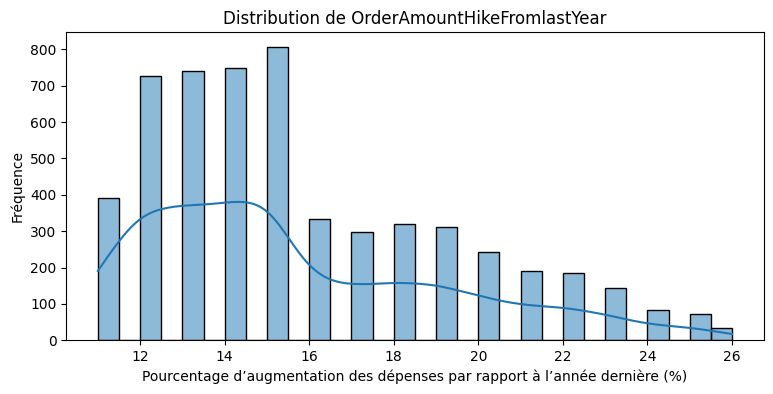

In [29]:
plt.figure(figsize=(9,4))
sns.histplot(data['OrderAmountHikeFromlastYear'], kde=True, bins=30)
plt.title("Distribution de OrderAmountHikeFromlastYear")
plt.xlabel("Pourcentage d’augmentation des dépenses par rapport à l’année dernière (%)")
plt.ylabel("Fréquence")
plt.show()

### 1.2.5. Visualisations avancées pour la modélisation

#### i. Feature importance (Random Forest)

        Pour voir quelles variables expliquent le Churn

#### ii. SHAP Values

        Explications détaillées des prédictions

In [ ]:
data.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,3.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


Train score: 1.0
Test score : 0.9630681818181818


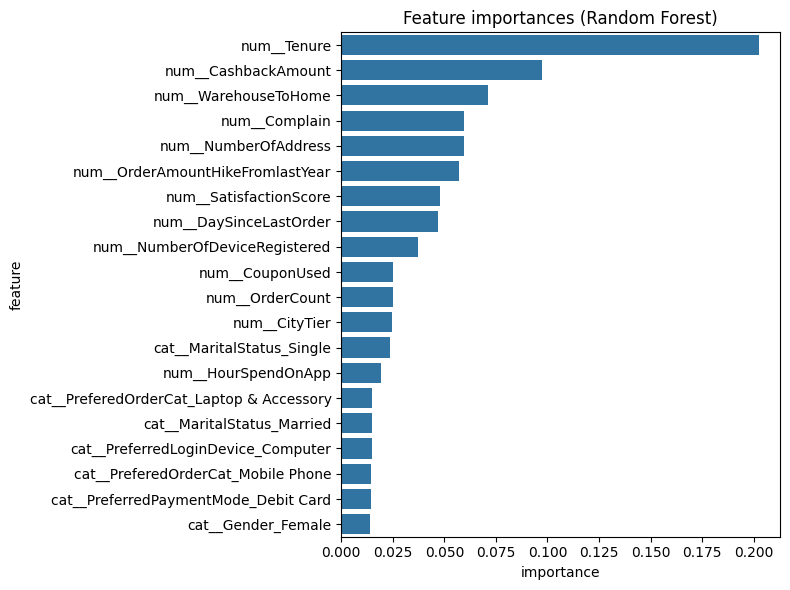

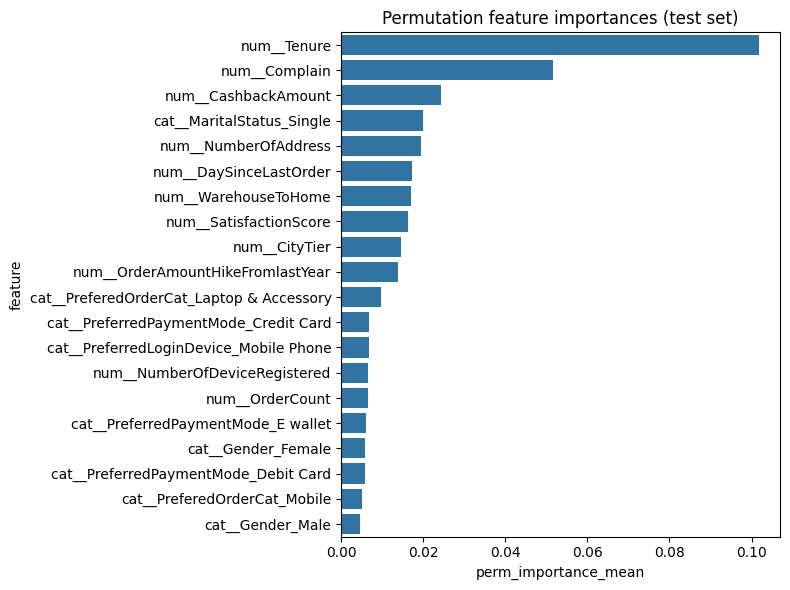

C:\Users\Midouni\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 98%|===================| 977/1000 [00:45<00:01]        

<Figure size 1000x600 with 0 Axes>

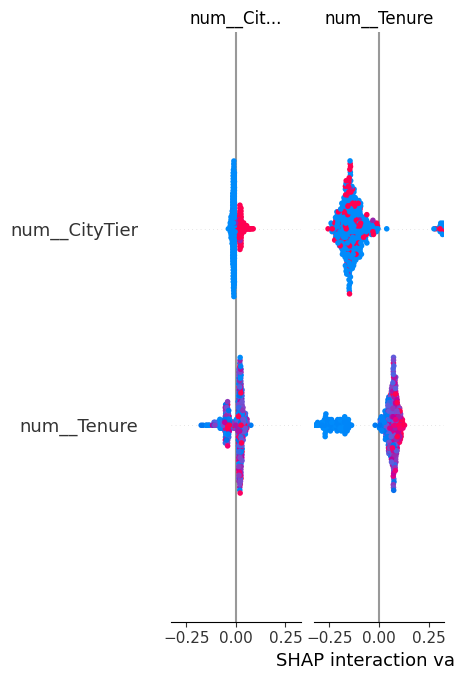

Erreur ou shap non installé : list index out of range
Pour installer shap : pip install shap


<Figure size 800x600 with 0 Axes>

In [35]:
# Prérequis : installer shap si besoin (décommente la ligne suivante)
# !pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Pour l'affichage des importances
from sklearn.inspection import permutation_importance

# --- 1) Préparation des données -------------------------------------------------
# data : ton DataFrame existant
# target : 'Churn'

# Séparer X et y
y = data['Churn']
X = data.drop(columns=['CustomerID', 'Churn'], errors='ignore')


# Identifier colonnes numériques et catégorielles
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Pipeline de preprocessing
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preproc = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
], remainder='drop')

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# --- 2) Pipeline modèle --------------------------------------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

pipe = Pipeline([
    ('preproc', preproc),
    ('rf', rf)
])

pipe.fit(X_train, y_train)

# Score simple
print("Train score:", pipe.score(X_train, y_train))
print("Test score :", pipe.score(X_test, y_test))

# --- 3) Feature importances (par RandomForest classique) ----------------------
# Récupérer noms de features après OneHotEncoding
feature_names = pipe.named_steps['preproc'].get_feature_names_out()

# importances du RandomForest
rf_model = pipe.named_steps['rf']
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)

# Plot top 20
plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title("Feature importances (Random Forest)")
plt.tight_layout()
plt.show()

# Optionnel : importance par permutation (plus fiable)
X_test_transformed = pipe.named_steps['preproc'].transform(X_test)

perm = permutation_importance(
    rf_model, # The final estimator (RandomForestClassifier)
    X_test_transformed, # Transformed test features
    y_test, # Test labels
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
perm_df = pd.DataFrame({'feature': feature_names, 'perm_importance_mean': perm.importances_mean})
perm_df = perm_df.sort_values('perm_importance_mean', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8,6))
sns.barplot(data=perm_df.head(20), x='perm_importance_mean', y='feature')
plt.title("Permutation feature importances (test set)")
plt.tight_layout()
plt.show()

# --- 4) SHAP : explications locales et globales --------------------------------
try:
    import shap
    # Utiliser TreeExplainer sur l'estimateur RandomForest appliqué aux features transformés
    # On a besoin de la matrice transformée (numpy)
    X_train_trans_np = pipe.named_steps['preproc'].transform(X_train)
    if not isinstance(X_train_trans_np, np.ndarray):
        X_train_trans_np = X_train_trans_np.toarray() # Ensure it's a dense array for SHAP

    explainer = shap.Explainer(rf_model, X_train_trans_np, feature_names=feature_names)

    # sélection d'un sous-ensemble pour performance
    X_sample = pipe.named_steps['preproc'].transform(X_test)
    if not isinstance(X_sample, np.ndarray):
        X_sample = X_sample.toarray()
    X_sample = X_sample[:500]  # limiter à 500 instances si dataset plus grand

    shap_values = explainer(X_sample)

    # SHAP summary plot (global)
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_values, features=X_sample, feature_names=feature_names, show=True)

    # Bar plot SHAP (importance moyenne absolue)
    plt.figure(figsize=(8,6))
    shap.plots.bar(shap_values, max_display=20)

    # Exemple d'explication locale (force plot) pour la première observation
    # Note : display dans notebook Jupyter, sinon sauvegarder en html
    shap.initjs()
    shap.force_plot(explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value,
                    shap_values[0].values, feature_names=feature_names, matplotlib=True)

except Exception as e:
    print("Erreur ou shap non installé :", e)
    print("Pour installer shap : pip install shap")

**commantaire**

L’analyse des importances de variables montre que Tenure (l’ancienneté du client) est de loin le facteur le plus déterminant du churn : les nouveaux clients sont nettement plus susceptibles de quitter le service. Viennent ensuite le montant moyen de cashback reçu et la distance entre l’entrepôt et le domicile, indiquant que les clients peu récompensés ou vivant loin du centre logistique ont tendance à être moins fidèles. Le nombre d’adresses enregistrées ainsi que la présence d’une plainte récente jouent également un rôle majeur dans la probabilité de churn, révélant l’importance de l’engagement et de la satisfaction client. Les valeurs SHAP confirment ces résultats et montrent en plus une interaction importante entre Tenure et CityTier : le risque de churn est particulièrement élevé pour les nouveaux clients résidant dans des villes de petite taille, alors que les clients plus anciens des grandes villes sont les plus fidèles. Cette combinaison souligne que la fidélité dépend non seulement de l’ancienneté, mais aussi du contexte géographique du client.